# Earthquake Alert Classification — Advanced Model Training
## Random Forest | Gradient Boosting | XGBoost | Cross-Validation | Hyperparameter Tuning

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('earthquake_processed.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1256, 8)


,magnitude,depth,cdi,mmi,sig,alert,depth_mag_ratio,alert_encoded
0,-0.143689,-0.352519,0.463323,0.060151,0.166882,green,-0.348561,0
1,-0.380035,-0.248606,-1.319015,-2.140313,-0.362421,green,-0.242449,0
2,-0.143689,4.984834,-1.764599,-2.873801,-0.041631,green,4.949339,0
3,0.565348,-0.135246,-0.873430,-1.406825,1.209449,green,-0.145434,0
4,-1.089073,5.409933,-3.101352,-3.607289,-1.404988,green,5.679250,0


## 2. Feature and Target Preparation

Feature matrix shape: (1256, 6)

Class distribution:
  0 (green): 322
  1 (yellow): 316
  2 (orange): 300
  3 (red): 318


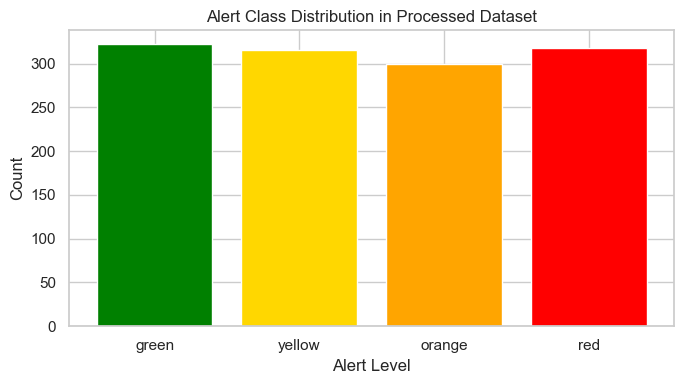

In [2]:
FEATURES = ['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'depth_mag_ratio']
TARGET   = 'alert_encoded'
LABEL_MAP = {0: 'green', 1: 'yellow', 2: 'orange', 3: 'red'}

X = df[FEATURES]
y = df[TARGET]

print("Feature matrix shape:", X.shape)
print("\nClass distribution:")
dist = y.value_counts().sort_index()
for k, v in dist.items():
    print(f"  {k} ({LABEL_MAP[k]}): {v}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([LABEL_MAP[i] for i in dist.index], dist.values, color=['green','gold','orange','red'])
ax.set_title('Alert Class Distribution in Processed Dataset')
ax.set_xlabel('Alert Level')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\nTraining class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTesting  class distribution:\n{y_test.value_counts().sort_index()}")

Training samples : 1004
Testing  samples : 252

Training class distribution:
alert_encoded
0    257
1    253
2    240
3    254
Name: count, dtype: int64

Testing  class distribution:
alert_encoded
0    65
1    63
2    60
3    64
Name: count, dtype: int64


## 4. Random Forest Classifier (Default)

Random Forest Accuracy: 0.9444

              precision    recall  f1-score   support

       green       0.97      0.91      0.94        65
      yellow       0.97      0.95      0.96        63
      orange       0.95      1.00      0.98        60
         red       0.89      0.92      0.91        64

    accuracy                           0.94       252
   macro avg       0.95      0.95      0.94       252
weighted avg       0.95      0.94      0.94       252



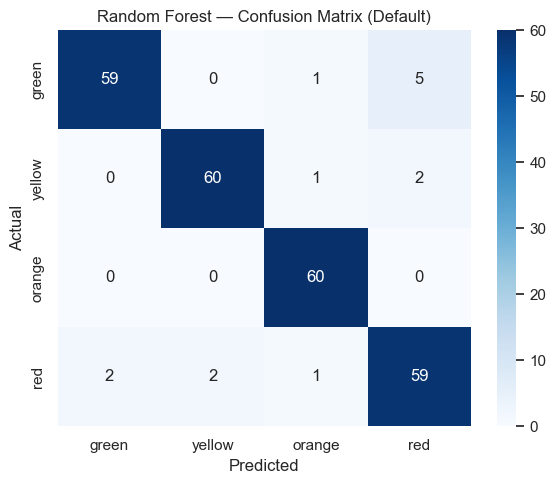

In [4]:
def plot_confusion_matrix(cm, title, classes=list(LABEL_MAP.values())):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
rf_pred = rf_default.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}\n")
print(classification_report(y_test, rf_pred, target_names=list(LABEL_MAP.values())))

plot_confusion_matrix(
    confusion_matrix(y_test, rf_pred),
    "Random Forest — Confusion Matrix (Default)"
)

## 5. Gradient Boosting Classifier (Default)

Gradient Boosting Accuracy: 0.9167

              precision    recall  f1-score   support

       green       0.97      0.86      0.91        65
      yellow       0.91      0.95      0.93        63
      orange       0.95      0.97      0.96        60
         red       0.85      0.89      0.87        64

    accuracy                           0.92       252
   macro avg       0.92      0.92      0.92       252
weighted avg       0.92      0.92      0.92       252



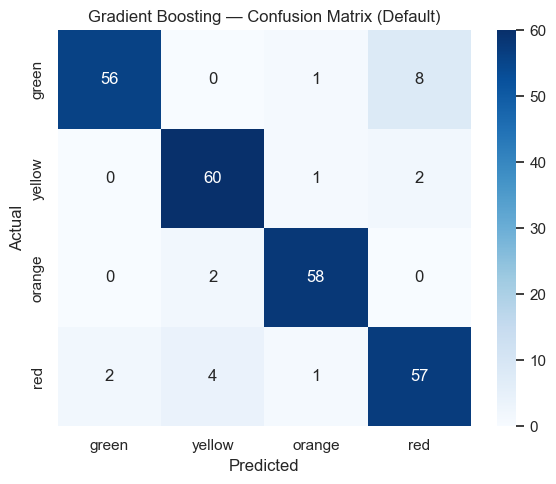

In [5]:
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train, y_train)
gb_pred = gb_default.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}\n")
print(classification_report(y_test, gb_pred, target_names=list(LABEL_MAP.values())))

plot_confusion_matrix(
    confusion_matrix(y_test, gb_pred),
    "Gradient Boosting — Confusion Matrix (Default)"
)

## 6. XGBoost Classifier (Default)

XGBoost Accuracy: 0.9563

              precision    recall  f1-score   support

       green       0.98      0.94      0.96        65
      yellow       0.95      0.97      0.96        63
      orange       0.95      0.98      0.97        60
         red       0.94      0.94      0.94        64

    accuracy                           0.96       252
   macro avg       0.96      0.96      0.96       252
weighted avg       0.96      0.96      0.96       252



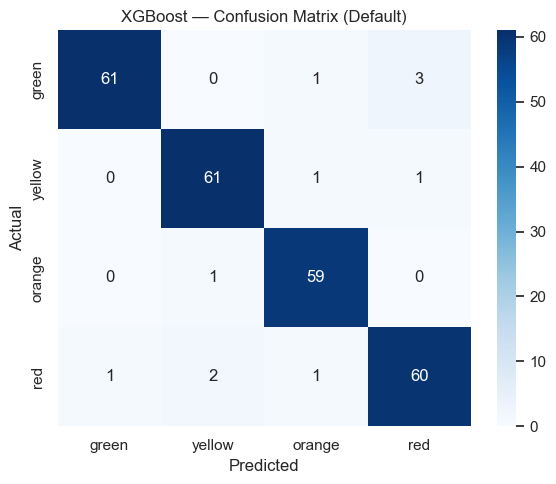

In [6]:
xgb_default = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_default.fit(X_train, y_train)
xgb_pred = xgb_default.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}\n")
print(classification_report(y_test, xgb_pred, target_names=list(LABEL_MAP.values())))

plot_confusion_matrix(
    confusion_matrix(y_test, xgb_pred),
    "XGBoost — Confusion Matrix (Default)"
)

## 7. Cross-Validation (k=5) — All Models

Random Forest          | CV Mean: 0.9084 | CV Std: 0.0138
Gradient Boosting      | CV Mean: 0.8877 | CV Std: 0.0099
XGBoost                | CV Mean: 0.9052 | CV Std: 0.0163


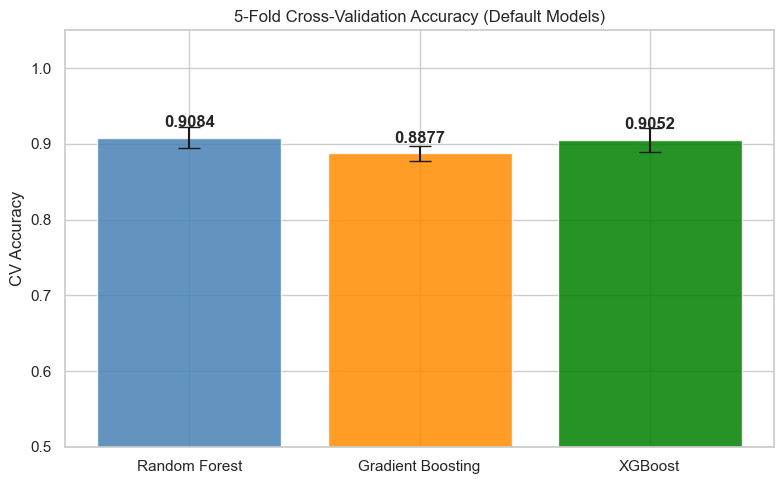

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_default = {
    'Random Forest':       rf_default,
    'Gradient Boosting':   gb_default,
    'XGBoost':             xgb_default
}

cv_results = {}
for name, model in models_default.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s} | CV Mean: {scores.mean():.4f} | CV Std: {scores.std():.4f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
bars  = ax.bar(names, means, yerr=stds, capsize=8, color=['steelblue', 'darkorange', 'green'], alpha=0.85)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy (Default Models)')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning with GridSearchCV / RandomizedSearchCV

### 8a. Random Forest — GridSearchCV

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters (RF): {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy  (RF): 0.8835
Test Accuracy     (RF): 0.9365
              precision    recall  f1-score   support

       green       0.97      0.88      0.92        65
      yellow       0.97      0.95      0.96        63
      orange       0.95      1.00      0.98        60
         red       0.87      0.92      0.89        64

    accuracy                           0.94       252
   macro avg       0.94      0.94      0.94       252
weighted avg       0.94      0.94      0.94       252



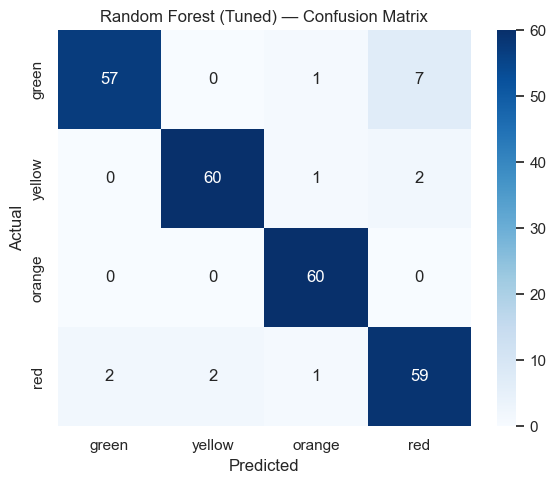

In [8]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print("Best Parameters (RF):", rf_grid.best_params_)
print(f"Best CV Accuracy  (RF): {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
rf_best_pred = rf_best.predict(X_test)
print(f"Test Accuracy     (RF): {accuracy_score(y_test, rf_best_pred):.4f}")
print(classification_report(y_test, rf_best_pred, target_names=list(LABEL_MAP.values())))
plot_confusion_matrix(confusion_matrix(y_test, rf_best_pred), "Random Forest (Tuned) — Confusion Matrix")

### 8b. Gradient Boosting — RandomizedSearchCV

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters (GB): {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 9, 'learning_rate': 0.1}
Best CV Accuracy  (GB): 0.8964
Test Accuracy     (GB): 0.9444
              precision    recall  f1-score   support

       green       0.98      0.91      0.94        65
      yellow       0.94      0.97      0.95        63
      orange       0.94      0.98      0.96        60
         red       0.92      0.92      0.92        64

    accuracy                           0.94       252
   macro avg       0.95      0.95      0.94       252
weighted avg       0.95      0.94      0.94       252



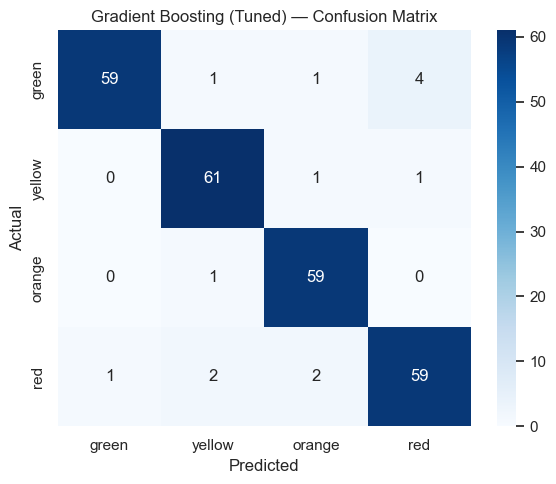

In [9]:
gb_param_dist = {
    'n_estimators':   [100, 200, 300, 400],
    'max_depth':      [3, 5, 7, 9],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_rand = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_dist,
    n_iter=30, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)
gb_rand.fit(X_train, y_train)

print("Best Parameters (GB):", gb_rand.best_params_)
print(f"Best CV Accuracy  (GB): {gb_rand.best_score_:.4f}")

gb_best = gb_rand.best_estimator_
gb_best_pred = gb_best.predict(X_test)
print(f"Test Accuracy     (GB): {accuracy_score(y_test, gb_best_pred):.4f}")
print(classification_report(y_test, gb_best_pred, target_names=list(LABEL_MAP.values())))
plot_confusion_matrix(confusion_matrix(y_test, gb_best_pred), "Gradient Boosting (Tuned) — Confusion Matrix")

### 8c. XGBoost — RandomizedSearchCV

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters (XGB): {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV Accuracy  (XGB): 0.8845
Test Accuracy     (XGB): 0.9444
              precision    recall  f1-score   support

       green       0.98      0.92      0.95        65
      yellow       0.94      0.97      0.95        63
      orange       0.94      0.98      0.96        60
         red       0.92      0.91      0.91        64

    accuracy                           0.94       252
   macro avg       0.94      0.95      0.94       252
weighted avg       0.95      0.94      0.94       252



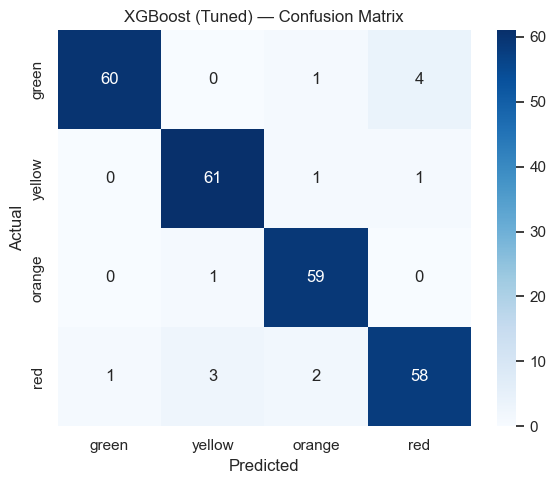

In [10]:
xgb_param_dist = {
    'n_estimators':   [100, 200, 300, 400],
    'max_depth':      [3, 5, 7, 9],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma':          [0, 0.1, 0.5, 1.0],
    'reg_alpha':      [0, 0.1, 1.0],
    'reg_lambda':     [1, 1.5, 2.0]
}

xgb_rand = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softmax', num_class=4,
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=42, n_jobs=-1
    ),
    xgb_param_dist,
    n_iter=30, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_rand.fit(X_train, y_train)

print("Best Parameters (XGB):", xgb_rand.best_params_)
print(f"Best CV Accuracy  (XGB): {xgb_rand.best_score_:.4f}")

xgb_best = xgb_rand.best_estimator_
xgb_best_pred = xgb_best.predict(X_test)
print(f"Test Accuracy     (XGB): {accuracy_score(y_test, xgb_best_pred):.4f}")
print(classification_report(y_test, xgb_best_pred, target_names=list(LABEL_MAP.values())))
plot_confusion_matrix(confusion_matrix(y_test, xgb_best_pred), "XGBoost (Tuned) — Confusion Matrix")

## 9. Model Comparison — Tuned Models

                   Accuracy  Precision    Recall  F1-Score
Model                                                     
Random Forest      0.936508   0.938241  0.936508  0.936455
Gradient Boosting  0.944444   0.945358  0.944444  0.944317
XGBoost            0.944444   0.945114  0.944444  0.944323


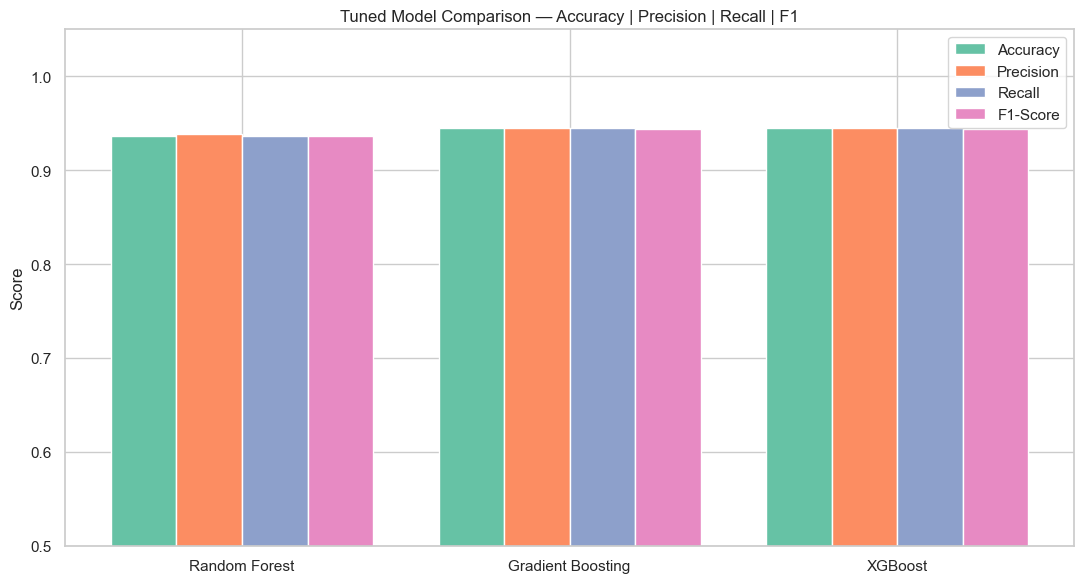

In [11]:
tuned_preds = {
    'Random Forest':     rf_best_pred,
    'Gradient Boosting': gb_best_pred,
    'XGBoost':           xgb_best_pred
}

metrics_records = []
for name, preds in tuned_preds.items():
    metrics_records.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall':    recall_score(y_test, preds, average='weighted'),
        'F1-Score':  f1_score(y_test, preds, average='weighted')
    })

metrics_df = pd.DataFrame(metrics_records).set_index('Model')
print(metrics_df.to_string())

# Grouped bar chart
metrics_melted = metrics_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette("Set2", 4)
x = np.arange(len(metrics_df))
width = 0.2
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metric_cols):
    ax.bar(x + i*width, metrics_df[metric], width, label=metric, color=colors[i])
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_df.index)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Tuned Model Comparison — Accuracy | Precision | Recall | F1')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Feature Importance Visualization — All Tuned Models

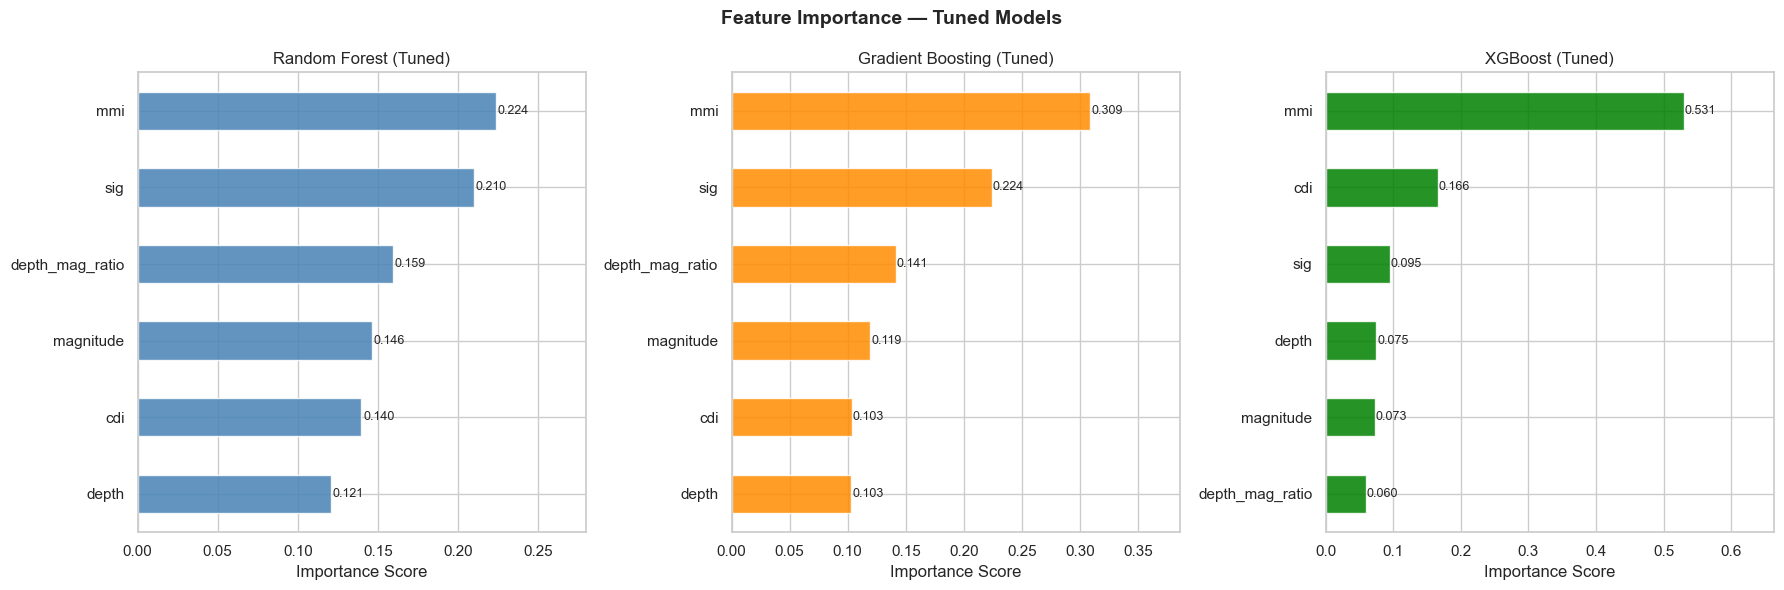


Feature Importance Summary:
                 Random Forest (Tuned)  Gradient Boosting (Tuned)  XGBoost (Tuned)
mmi                             0.2239                     0.3088           0.5305
sig                             0.2099                     0.2239           0.0953
depth_mag_ratio                 0.1593                     0.1413           0.0596
magnitude                       0.1465                     0.1195           0.0734
cdi                             0.1397                     0.1033           0.1659
depth                           0.1208                     0.1032           0.0752


In [12]:
importance_models = {
    'Random Forest (Tuned)':     rf_best,
    'Gradient Boosting (Tuned)': gb_best,
    'XGBoost (Tuned)':           xgb_best
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_fi = ['steelblue', 'darkorange', 'green']

for ax, (name, model), color in zip(axes, importance_models.items(), colors_fi):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, importances.max() * 1.25)
    for i, v in enumerate(importances):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — Tuned Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
fi_df = pd.DataFrame(
    {name: model.feature_importances_ for name, model in importance_models.items()},
    index=FEATURES
).sort_values('Random Forest (Tuned)', ascending=False)
print("\nFeature Importance Summary:")
print(fi_df.round(4).to_string())